In [1]:
"""
NB10_Multi_Orbit_Truth_Validation

Purpose
-------
Validate the multi-orbit iterated encounter map (NB08) against
truth propagation over N revolutions.

1) Propagate r,v under full SH gravity (DOP853) for N orbits.
2) Segment the truth trajectory into individual revolutions.
3) For each revolution, extract the osculating Δe₂D (truth).
4) Compare per-orbit truth Δe against NB08 Mode A prediction
   (frozen de2d_full_1 repeated each orbit).
5) Compare cumulative truth e(t) against iterated map prediction.

Dependencies: NB03, NB05 (de2d_full, basis), gravity evaluator, scipy
"""

from __future__ import annotations

import json, time, math
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Cell 1 : Config and Auto-discover
# ============================================================
ART_DIR = Path("./artifacts")

nb03_files = sorted(ART_DIR.glob("dg_samples_NB03_*_L*.npz"))
nb05_files = sorted(ART_DIR.glob("deltae_NB05_*.npz"))
if not nb03_files: raise FileNotFoundError("No NB03 artifact.")
if not nb05_files: raise FileNotFoundError("No NB05 artifact.")

DG_NPZ   = nb03_files[-1]
NB05_NPZ = nb05_files[-1]

RUN_TAG = datetime.now(timezone.utc).strftime("NB10_%Y%m%dT%H%M%SZ")
OUT_NPZ = ART_DIR / f"multi_truth_{RUN_TAG}.npz"
OUT_JSON = ART_DIR / f"multi_truth_{RUN_TAG}.json"

N_ORBITS = 10  # adjust based on compute budget; L=200 DOP853 ~2s/orbit

INT_METHOD = "DOP853"; INT_RTOL = 1e-11; INT_ATOL = 1e-12

print(f"NB03: {DG_NPZ.name}")
print(f"NB05: {NB05_NPZ.name}")
print(f"N_ORBITS = {N_ORBITS}")
print(f"Integrator: {INT_METHOD} rtol={INT_RTOL} atol={INT_ATOL}")

NB03: dg_samples_NB03_20260316T033826Z_L200.npz
NB05: deltae_NB05_20260316T125355Z.npz
N_ORBITS = 10
Integrator: DOP853 rtol=1e-11 atol=1e-12


In [3]:
# ============================================================
# Cell 2 : Load Data
# ============================================================
dg = np.load(DG_NPZ, allow_pickle=False)
nb5 = np.load(NB05_NPZ, allow_pickle=False)

r0 = dg["r_eci"][0].astype(float).copy()
v0 = dg["v_eci"][0].astype(float).copy()
t_1orbit = dg["t"].astype(float)
T_orbit = float(t_1orbit[-1] - t_1orbit[0])  # one orbital period [s]

meta_dg = json.loads(str(dg["meta_json"])) if "meta_json" in dg else {}
_op = meta_dg.get("orbit_params", meta_dg.get("orbit_params_from_npz", {}))
omega = float(_op.get("omega_rad_s", _op.get("omega_used_in_nb02", 2.6616995e-6)))
_gm = meta_dg.get("gravity_model", meta_dg.get("gravity_model_from_pds", {}))
mu = float(_gm.get("GM_km3_s2", 4902.800076))
L  = int(_gm.get("L_used", meta_dg.get("L", 200)))

de2d_full_1 = nb5["de2d_full"].astype(float).ravel()  # per-orbit Δe from NB05
F_amp       = float(nb5["F_amp"])
p_hat       = nb5["p_hat"].astype(float)
q_hat       = nb5["q_hat"].astype(float)

# Total propagation span
t_total = T_orbit * N_ORBITS

# Time grid: dense within each orbit to extract osculating elements
M_per_orbit = 200  # samples per orbit for element extraction
t_eval = np.linspace(0.0, t_total, N_ORBITS * M_per_orbit + 1)

print(f"T_orbit = {T_orbit:.2f} s")
print(f"Total propagation: {t_total:.2f} s = {t_total/3600:.2f} hr = {N_ORBITS} orbits")
print(f"mu={mu}, omega={omega:.7e}, L={L}")
print(f"de2d_full_1 = [{de2d_full_1[0]:+.6e}, {de2d_full_1[1]:+.6e}]")

T_orbit = 6779.25 s
Total propagation: 67792.53 s = 18.83 hr = 10 orbits
mu=4902.79996708864, omega=2.6616995e-06, L=200
de2d_full_1 = [+3.490250e-05, +2.759606e-04]


In [4]:
# ============================================================
# Cell 3 : Gravity Evaluator + Frame Transforms
# ============================================================
_need_grav = False
try:
    _ = gravity_accel_sph_harm; _ = sh
    print("Gravity evaluator in namespace.")
except NameError:
    print("Loading gravity evaluator inline...")
    _need_grav = True

if _need_grav:
    from dataclasses import dataclass
    try:
        from numba import njit
    except ImportError:
        def njit(*a, **kw):
            def w(fn): return fn
            if len(a)==1 and callable(a[0]): return a[0]
            return w

    LOCAL_SHA_PATH = Path("./gravity_models/gggrx_0900c_sha.tab")
    if not LOCAL_SHA_PATH.exists():
        raise FileNotFoundError(f"Missing {LOCAL_SHA_PATH}. Run NB01 first.")

    @dataclass
    class SHModel:
        C: np.ndarray; S: np.ndarray; sigmaC: np.ndarray; sigmaS: np.ndarray
        Lmax: int; mu_km3_s2: float; Rref_km: float; normalized: bool; source: str

    def parse_gggrx_pds3_fixed(path):
        lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
        parts = [p.strip() for p in lines[0].split(",") if p.strip()]
        Rref_km=float(parts[0]);mu_km3_s2=float(parts[1])
        Lmax=int(float(parts[3]));normalized=(int(float(parts[5]))==1)
        C=np.zeros((Lmax+1,Lmax+1));S=np.zeros_like(C)
        sigmaC=np.zeros_like(C);sigmaS=np.zeros_like(C)
        for ln in lines[2:]:
            if not ln.strip() or len(ln)<107: continue
            try:
                l=int(ln[0:5]);m=int(ln[6:11])
                C[l,m]=float(ln[12:35]);S[l,m]=float(ln[36:59])
                sigmaC[l,m]=float(ln[60:83]);sigmaS[l,m]=float(ln[84:107])
            except: continue
        if C[0,0]==0.0: C[0,0]=1.0
        return SHModel(C=C,S=S,sigmaC=sigmaC,sigmaS=sigmaS,Lmax=Lmax,
                       mu_km3_s2=mu_km3_s2,Rref_km=Rref_km,normalized=normalized,source=str(path))

    sh = parse_gggrx_pds3_fixed(LOCAL_SHA_PATH)

    @njit(cache=True)
    def _fully_normalized_legendre(sin_phi,cos_phi,L):
        Pbar=np.zeros((L+1,L+1));dPbar=np.zeros((L+1,L+1));Pbar[0,0]=1.0
        for m in range(1,L+1):
            fac=math.sqrt((2.*m+1.)/(2.*m))
            Pbar[m,m]=cos_phi*fac*Pbar[m-1,m-1]
            dPbar[m,m]=fac*(-sin_phi*Pbar[m-1,m-1]+cos_phi*dPbar[m-1,m-1])
        for m in range(0,L):
            fac=math.sqrt(2.*m+3.)
            Pbar[m+1,m]=sin_phi*fac*Pbar[m,m]
            dPbar[m+1,m]=fac*(cos_phi*Pbar[m,m]+sin_phi*dPbar[m,m])
        for m in range(0,L+1):
            for l in range(m+2,L+1):
                ls=float(l);ms=float(m)
                a=math.sqrt((4.*ls*ls-1.)/(ls*ls-ms*ms))
                b=math.sqrt(((ls-1.)**2-ms*ms)/(4.*(ls-1.)**2-1.))
                Pbar[l,m]=a*(sin_phi*Pbar[l-1,m]-b*Pbar[l-2,m])
                dPbar[l,m]=a*(cos_phi*Pbar[l-1,m]+sin_phi*dPbar[l-1,m]-b*dPbar[l-2,m])
        return Pbar,dPbar

    EPS_POLE=1e-10
    @njit(cache=True)
    def _sh_sum(C,S,P,dP,L,mu,a,r,lam,sp,cp):
        cosml=np.empty(L+1);sinml=np.empty(L+1);cosml[0]=1.;sinml[0]=0.
        c1=math.cos(lam);s1=math.sin(lam)
        for m in range(1,L+1):cosml[m]=cosml[m-1]*c1-sinml[m-1]*s1;sinml[m]=sinml[m-1]*c1+cosml[m-1]*s1
        rho=a/r;ar=0.;ap=0.;al=0.;rho_l=1.
        for l in range(0,L+1):
            if l>0:rho_l*=rho
            sV=0.;sd=0.;sl=0.
            for m in range(0,l+1):
                t=C[l,m]*cosml[m]+S[l,m]*sinml[m]
                sV+=P[l,m]*t;sd+=dP[l,m]*t
                if m>0:sl+=P[l,m]*m*(-C[l,m]*sinml[m]+S[l,m]*cosml[m])
            ar+=(l+1)*rho_l*sV;ap+=rho_l*sd;al+=rho_l*sl
        r2=r*r;return -(mu/r2)*ar,-(mu/r2)*ap,-(mu/r2)*(al/cp)

    def gravity_accel_sph_harm(sh,r_bf,degree=50):
        x,y,z=float(r_bf[0]),float(r_bf[1]),float(r_bf[2])
        r=math.sqrt(x*x+y*y+z*z);lam=math.atan2(y,x);sp=z/r
        cp=math.sqrt(max(0.,1.-sp*sp))
        if cp<EPS_POLE:sp=math.copysign(math.sqrt(1.-EPS_POLE**2),sp);cp=EPS_POLE
        Ld=min(int(degree),sh.Lmax)
        P,dP=_fully_normalized_legendre(sp,cp,Ld)
        ar,ap,al=_sh_sum(sh.C,sh.S,P,dP,Ld,sh.mu_km3_s2,sh.Rref_km,r,lam,sp,cp)
        cl=math.cos(lam);sl=math.sin(lam)
        return np.array([ar*cp*cl+ap*(-sp)*cl+al*(-sl),ar*cp*sl+ap*(-sp)*sl+al*cl,ar*sp+ap*cp])

    print(f"  Loaded: Lmax={sh.Lmax}")

def _R3(th):
    c=np.cos(th);s=np.sin(th)
    return np.array([[c,-s,0],[s,c,0],[0,0,1.]])
def eci2fix(r,t_s): return _R3(-omega*t_s)@r
def fix2eci(v,t_s): return _R3(+omega*t_s)@v

print(f"Using L = {L}")

Loading gravity evaluator inline...
  Loaded: Lmax=900
Using L = 200


In [5]:
# ============================================================
# Cell 4 : Propagate N Orbits
# ============================================================
def eom(t_s, y):
    r_mf = eci2fix(y[:3], t_s)
    g_mf = gravity_accel_sph_harm(sh, r_mf, degree=L)
    g_eci = fix2eci(g_mf, t_s)
    return np.concatenate([y[3:], g_eci])

y0 = np.concatenate([r0, v0])

print(f"Propagating {N_ORBITS} orbits ({t_total:.0f} s = {t_total/3600:.1f} hr)...")
t0_wall = time.time()
sol = solve_ivp(eom, [0.0, t_total], y0, method=INT_METHOD,
                t_eval=t_eval, rtol=INT_RTOL, atol=INT_ATOL)
elapsed = time.time() - t0_wall

if not sol.success:
    raise RuntimeError(f"Integration failed: {sol.message}")

r_all = sol.y[:3].T
v_all = sol.y[3:].T
t_all = sol.t

print(f"Done in {elapsed:.1f}s  ({sol.nfev} evals, {elapsed/N_ORBITS:.1f} s/orbit)")
print(f"Total samples: {t_all.size}")

Propagating 10 orbits (67793 s = 18.8 hr)...
Done in 13.5s  (52955 evals, 1.3 s/orbit)
Total samples: 2001


In [6]:
# ============================================================
# Cell 5 : Segment into Orbits and Extract Per-Orbit Δe
# ============================================================
# For each orbit k, find the time boundaries [k*T, (k+1)*T],
# extract osculating e-vector at start and end, compute Δe_k.

# Osculating e-vector at every sample
rnorm_all = np.linalg.norm(r_all, axis=1)
hvec_all  = np.cross(r_all, v_all)
vxh_all   = np.cross(v_all, hvec_all)
evec_all  = vxh_all / mu - r_all / rnorm_all[:, None]

# Project into fixed (p, q) basis
ep_all = evec_all @ p_hat
eq_all = evec_all @ q_hat

# Per-orbit Δe: find samples closest to orbit boundaries
de2d_truth_per_orbit = np.zeros((N_ORBITS, 2))
orbit_boundary_idx = np.zeros(N_ORBITS + 1, dtype=int)

for k in range(N_ORBITS + 1):
    t_boundary = k * T_orbit
    orbit_boundary_idx[k] = int(np.argmin(np.abs(t_all - t_boundary)))

for k in range(N_ORBITS):
    i0 = orbit_boundary_idx[k]
    i1 = orbit_boundary_idx[k + 1]
    de2d_truth_per_orbit[k, 0] = ep_all[i1] - ep_all[i0]
    de2d_truth_per_orbit[k, 1] = eq_all[i1] - eq_all[i0]

de2d_truth_norms = np.linalg.norm(de2d_truth_per_orbit, axis=1)

# Cumulative truth Δe (relative to t=0)
de2d_truth_cum = np.zeros((N_ORBITS, 2))
for k in range(N_ORBITS):
    i1 = orbit_boundary_idx[k + 1]
    de2d_truth_cum[k, 0] = ep_all[i1] - ep_all[0]
    de2d_truth_cum[k, 1] = eq_all[i1] - eq_all[0]

de2d_truth_cum_norms = np.linalg.norm(de2d_truth_cum, axis=1)

# Map prediction (Mode A: frozen increment)
de2d_pred_per_orbit = np.tile(de2d_full_1, (N_ORBITS, 1))  # same each orbit
de2d_pred_cum = np.array([(k+1) * de2d_full_1 for k in range(N_ORBITS)])
de2d_pred_cum_norms = np.linalg.norm(de2d_pred_cum, axis=1)

print(f"Per-orbit truth ||Δe||: min={de2d_truth_norms.min():.4e}  max={de2d_truth_norms.max():.4e}  mean={de2d_truth_norms.mean():.4e}")
print(f"Map prediction ||Δe||:  {np.linalg.norm(de2d_full_1):.4e} (constant)")

Per-orbit truth ||Δe||: min=2.0167e-04  max=4.5580e-04  mean=3.0904e-04
Map prediction ||Δe||:  2.7816e-04 (constant)


In [7]:
# ============================================================
# Cell 6 : Comparison Table
# ============================================================
# Per-orbit errors
err_per_orbit = np.linalg.norm(de2d_truth_per_orbit - de2d_pred_per_orbit, axis=1)
rel_err_per_orbit = err_per_orbit / np.maximum(de2d_truth_norms, 1e-30)

# Cumulative errors
err_cum = np.linalg.norm(de2d_truth_cum - de2d_pred_cum, axis=1)
rel_err_cum = err_cum / np.maximum(de2d_truth_cum_norms, 1e-30)

print(f"{'='*75}")
print(f"  MULTI-ORBIT VALIDATION: Map vs Truth  ({N_ORBITS} orbits)")
print(f"{'='*75}")
print(f"{'Orbit':>5s}  {'||de_truth||':>12s}  {'||de_map||':>12s}  {'Inc Err':>10s}  {'Cum Err%':>10s}")
print(f"{'-'*5}  {'-'*12}  {'-'*12}  {'-'*10}  {'-'*10}")
for k in range(N_ORBITS):
    print(f"{k+1:5d}  {de2d_truth_norms[k]:12.4e}  {np.linalg.norm(de2d_full_1):12.4e}  "
          f"{rel_err_per_orbit[k]*100:9.2f}%  {rel_err_cum[k]*100:9.2f}%")

print(f"\nSummary:")
print(f"  Per-orbit rel error: mean={rel_err_per_orbit.mean()*100:.2f}%  max={rel_err_per_orbit.max()*100:.2f}%")
print(f"  Cumulative rel error at orbit {N_ORBITS}: {rel_err_cum[-1]*100:.2f}%")

  MULTI-ORBIT VALIDATION: Map vs Truth  (10 orbits)
Orbit  ||de_truth||    ||de_map||     Inc Err    Cum Err%
-----  ------------  ------------  ----------  ----------
    1    2.7531e-04    2.7816e-04       1.20%       1.20%
    2    2.2476e-04    2.7816e-04      25.16%      11.77%
    3    2.0167e-04    2.7816e-04      41.86%      20.42%
    4    2.1240e-04    2.7816e-04      37.58%      24.34%
    5    2.4869e-04    2.7816e-04      23.15%      23.52%
    6    2.9804e-04    2.7816e-04      17.86%      19.79%
    7    3.5037e-04    2.7816e-04      23.92%      15.32%
    8    3.9540e-04    2.7816e-04      30.65%      12.23%
    9    4.2794e-04    2.7816e-04      35.31%      11.84%
   10    4.5580e-04    2.7816e-04      39.15%      13.77%

Summary:
  Per-orbit rel error: mean=27.58%  max=41.86%
  Cumulative rel error at orbit 10: 13.77%


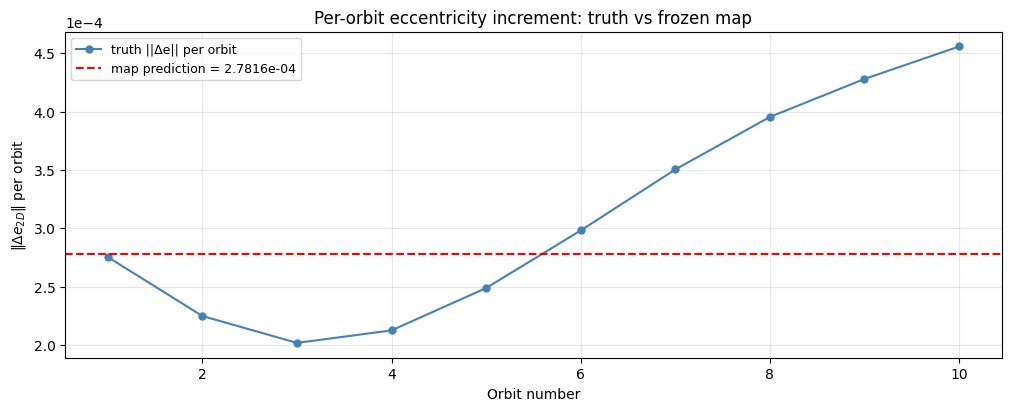

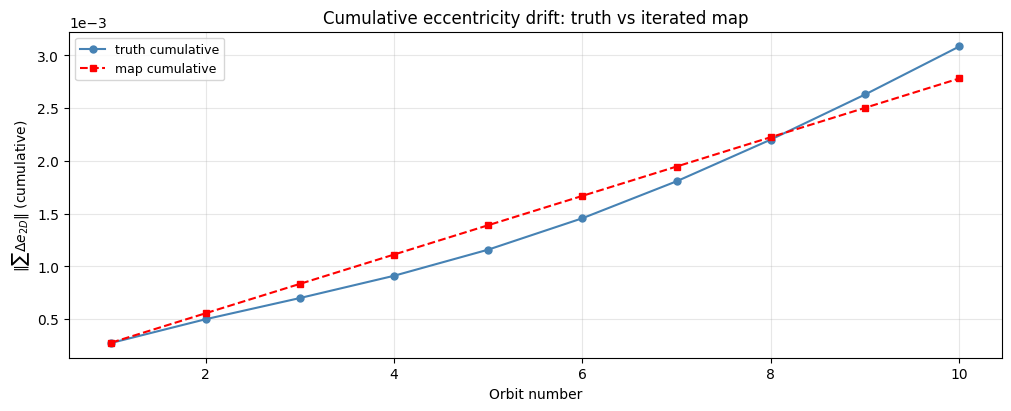

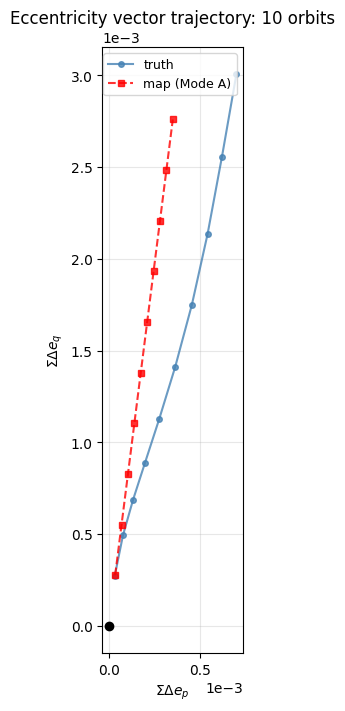

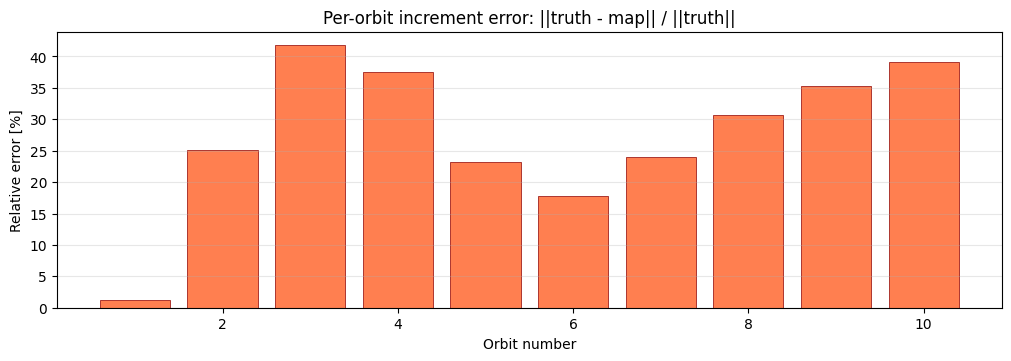

In [8]:
# ============================================================
# Cell 7 : Plots
# ============================================================
orbits = np.arange(1, N_ORBITS + 1)

# --- Plot 1: Per-orbit ||Δe|| truth vs map ---
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.plot(orbits, de2d_truth_norms, "o-", color="steelblue", ms=5, lw=1.5, label="truth ||Δe|| per orbit")
ax.axhline(np.linalg.norm(de2d_full_1), color="red", ls="--", lw=1.5,
           label=f"map prediction = {np.linalg.norm(de2d_full_1):.4e}")
ax.set_xlabel("Orbit number")
ax.set_ylabel(r"$\|\Delta e_{2D}\|$ per orbit")
ax.set_title("Per-orbit eccentricity increment: truth vs frozen map")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.ticklabel_format(axis="y", style="scientific", scilimits=(-4,-4))
plt.show()

# --- Plot 2: Cumulative ||Σ Δe|| truth vs map ---
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.plot(orbits, de2d_truth_cum_norms, "o-", color="steelblue", ms=5, lw=1.5, label="truth cumulative")
ax.plot(orbits, de2d_pred_cum_norms, "s--", color="red", ms=4, lw=1.5, label="map cumulative")
ax.set_xlabel("Orbit number")
ax.set_ylabel(r"$\|\sum \Delta e_{2D}\|$ (cumulative)")
ax.set_title("Cumulative eccentricity drift: truth vs iterated map")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.ticklabel_format(axis="y", style="scientific", scilimits=(-3,-3))
plt.show()

# --- Plot 3: Cumulative Δe in (p,q) plane ---
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.plot(de2d_truth_cum[:, 0], de2d_truth_cum[:, 1], "o-", ms=4, color="steelblue",
        label="truth", alpha=0.8)
ax.plot(de2d_pred_cum[:, 0], de2d_pred_cum[:, 1], "s--", ms=4, color="red",
        label="map (Mode A)", alpha=0.8)
ax.plot(0, 0, "ko", ms=6)
ax.set_xlabel(r"$\Sigma \Delta e_p$"); ax.set_ylabel(r"$\Sigma \Delta e_q$")
ax.set_title(f"Eccentricity vector trajectory: {N_ORBITS} orbits")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.ticklabel_format(style="scientific", scilimits=(-3,-3))
plt.show()

# --- Plot 4: Per-orbit relative error ---
fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
ax.bar(orbits, rel_err_per_orbit * 100, color="coral", edgecolor="darkred", lw=0.5)
ax.set_xlabel("Orbit number")
ax.set_ylabel("Relative error [%]")
ax.set_title("Per-orbit increment error: ||truth - map|| / ||truth||")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

In [9]:
# ============================================================
# Cell 8 : Save
# ============================================================
meta = {
    "run_tag": RUN_TAG, "N_orbits": N_ORBITS,
    "T_orbit_s": T_orbit, "total_s": t_total,
    "integrator": f"{INT_METHOD} rtol={INT_RTOL} atol={INT_ATOL}",
    "nfev": int(sol.nfev), "elapsed_s": round(elapsed, 2),
    "nb03_npz": str(DG_NPZ), "nb05_npz": str(NB05_NPZ),
    "per_orbit_rel_err_mean_pct": round(float(rel_err_per_orbit.mean() * 100), 2),
    "per_orbit_rel_err_max_pct":  round(float(rel_err_per_orbit.max() * 100), 2),
    "cum_rel_err_final_pct":      round(float(rel_err_cum[-1] * 100), 2),
}

np.savez(OUT_NPZ,
    t_all=t_all, r_all=r_all, v_all=v_all,
    ep_all=ep_all, eq_all=eq_all,
    orbit_boundary_idx=orbit_boundary_idx,
    de2d_truth_per_orbit=de2d_truth_per_orbit,
    de2d_truth_cum=de2d_truth_cum,
    de2d_pred_per_orbit=de2d_pred_per_orbit,
    de2d_pred_cum=de2d_pred_cum,
    rel_err_per_orbit=rel_err_per_orbit,
    rel_err_cum=rel_err_cum,
    meta_json=json.dumps(meta),
)
OUT_JSON.write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved: {OUT_NPZ}")
print(f"Saved: {OUT_JSON}")
print(f"\n--- NB10 complete ---")

Saved: artifacts\multi_truth_NB10_20260316T142325Z.npz
Saved: artifacts\multi_truth_NB10_20260316T142325Z.json

--- NB10 complete ---
